In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

<b>Understand Size, Data Types, and Data Issues in the Dataset</b>

In [3]:
df=pd.read_csv('../data/Telco-Customer-Churn-Raw.csv')
print("Shape:", df.shape)
print(df.head())
df.info()

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

 <b> Observations</b><br>
+ Dataset has 7043 rows, 21 columns<br>
+ Mix of categorical and numerical features<br>
+ TotalCharges is incorrectly stored as object<br>
+ No explicit missing values shown<br>

<b>Checking for Null Values and Churn Distribution</b>

In [4]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

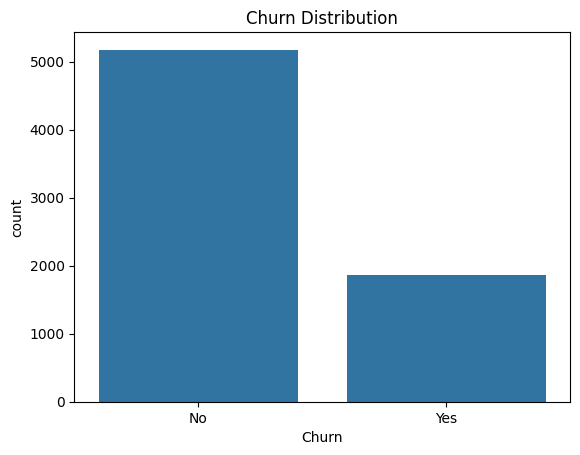

In [5]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

<b>Insight</b><br>
+ ~26% churned customers<br>
+ Dataset is moderately imbalanced<br>
+ Accuracy alone can be misleading, therefore, use ROC-AUC, Recall, F1

In [6]:
print(df.isnull().sum())
print((df['TotalCharges'] == " ").sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
11


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


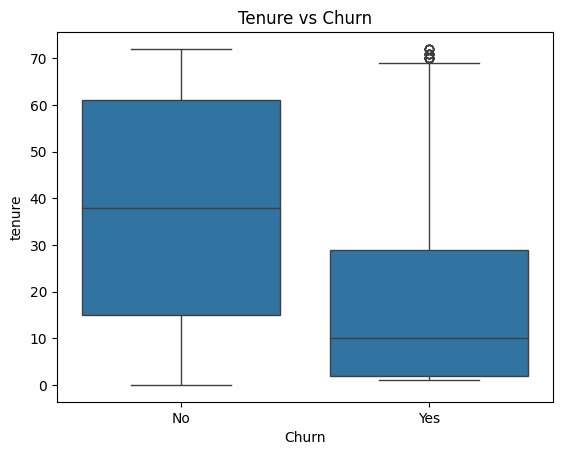

In [8]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

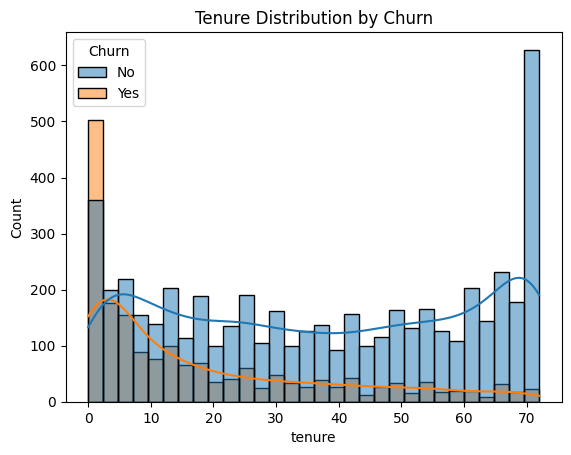

In [9]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

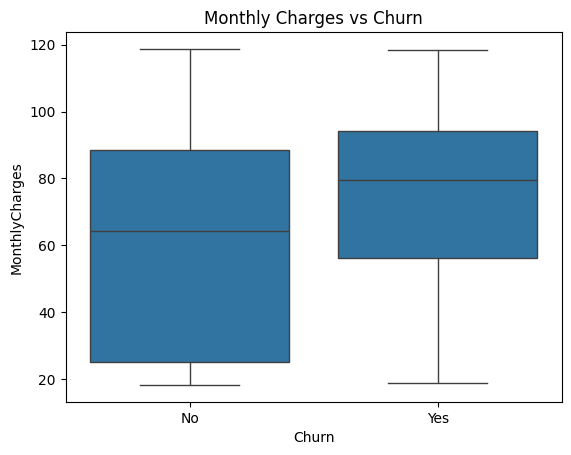

In [10]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

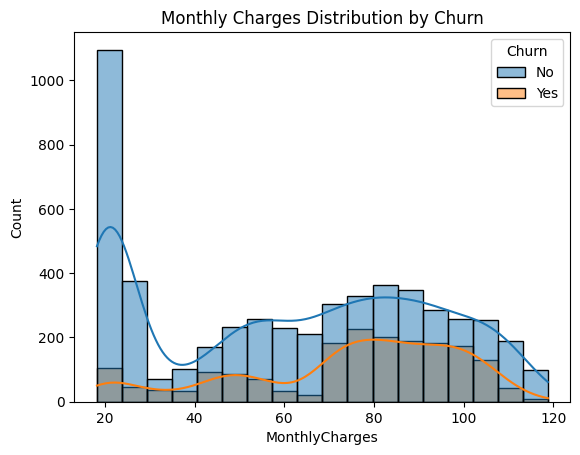

In [11]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

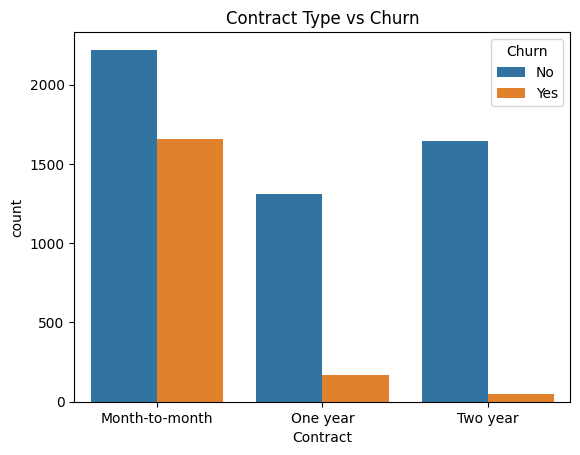

In [12]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.show()

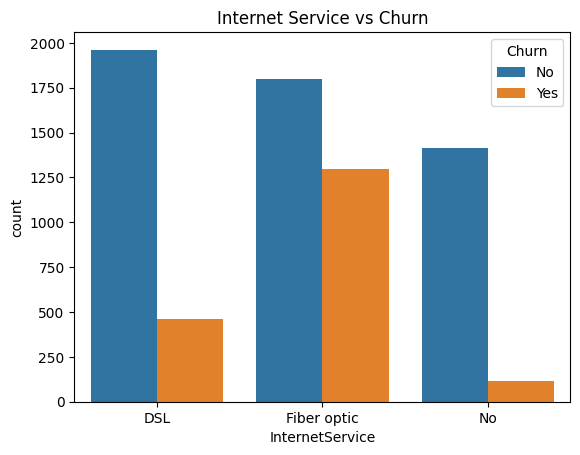

In [13]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

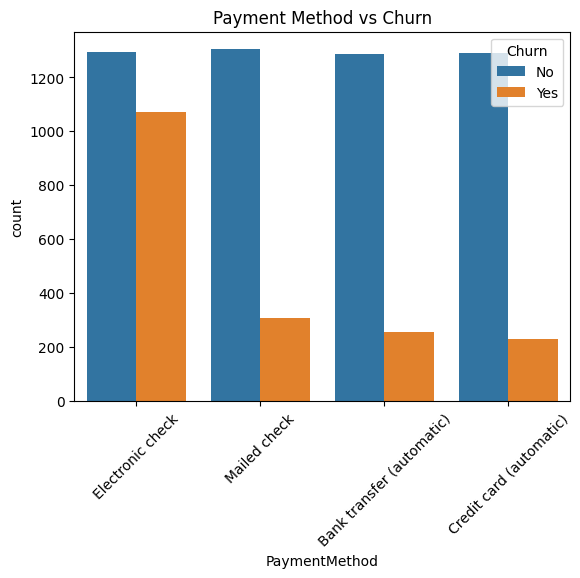

In [14]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

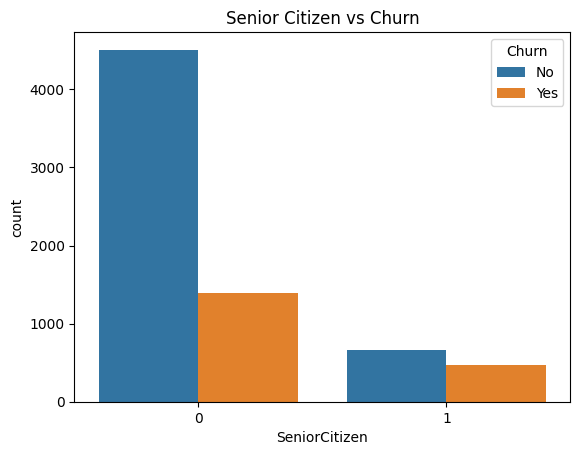

In [15]:
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

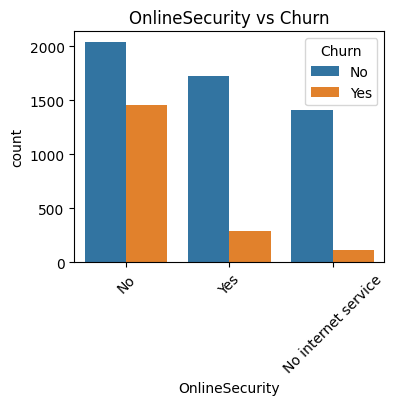

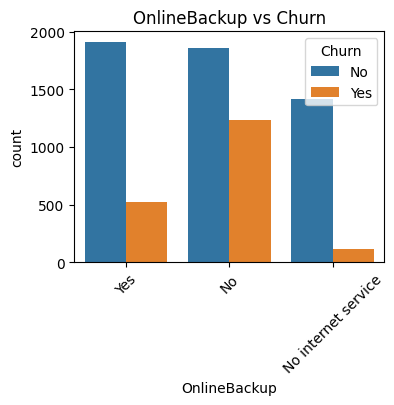

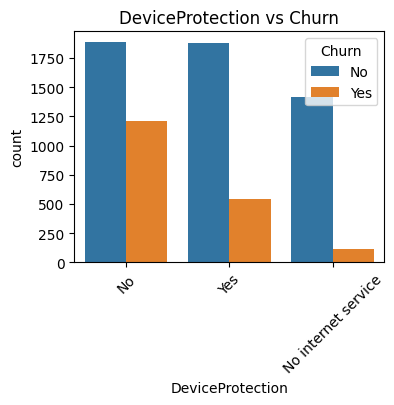

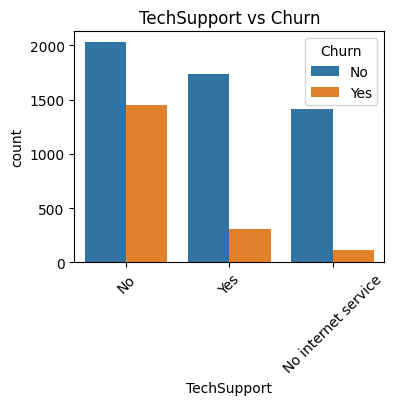

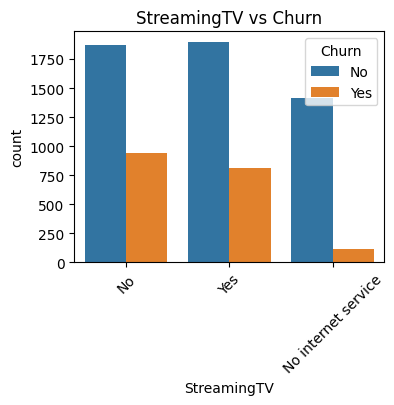

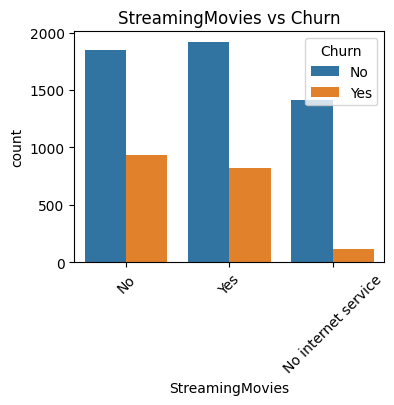

In [16]:
services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in services:
    plt.figure(figsize=(4,3))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

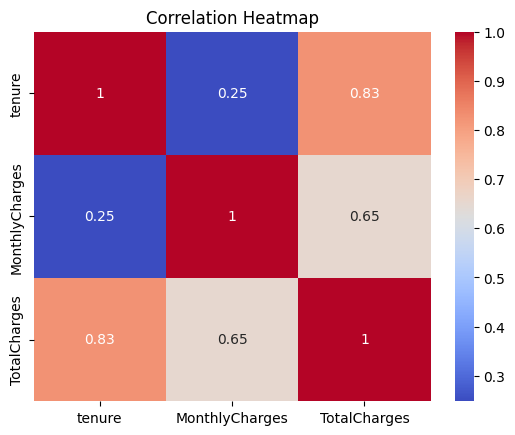

In [17]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")  
plt.show()

<b>Encoding Categorical Variables for Correlation Analysis</b>

In [22]:
from sklearn.preprocessing import OneHotEncoder

# Create a copy for encoding
df_encoded = df.copy()

# Binary columns
binary_cols = ['Churn', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in df_encoded.columns:
        df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# Categorical columns to encode
cat_cols = ['gender', 'InternetService', 'MultipleLines','OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'BillingCycle', 'PaymentMethod']

for col in cat_cols:
    if col in df_encoded.columns:
        ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' to avoid multicollinearity
        encoded_cols = ohe.fit_transform(df_encoded[[col]])
        encoded_col_names = [f"{col}_{cat}" for cat in ohe.categories_[0][1:]]  # Skip first category (reference)
        df_encoded[encoded_col_names] = encoded_cols
        df_encoded = df_encoded.drop(columns=[col])  # Drop original categorical column

print("Encoded data shape:", df_encoded.shape)
print("Data types after encoding:")
print(df_encoded.dtypes)


Encoded data shape: (7043, 32)
Data types after encoding:
customerID                                object
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                              float64
InternetService_Fiber optic              float64
InternetService_No                       float64
MultipleLines_No phone service           float64
MultipleLines_Yes                        float64
OnlineSecurity_No internet service       float64
OnlineSecurity_Yes                       float64
OnlineBackup_No internet service         float64
OnlineBackup_Yes                         float64
DeviceProte

<b>Full Correlation Matrix with All Features</b>

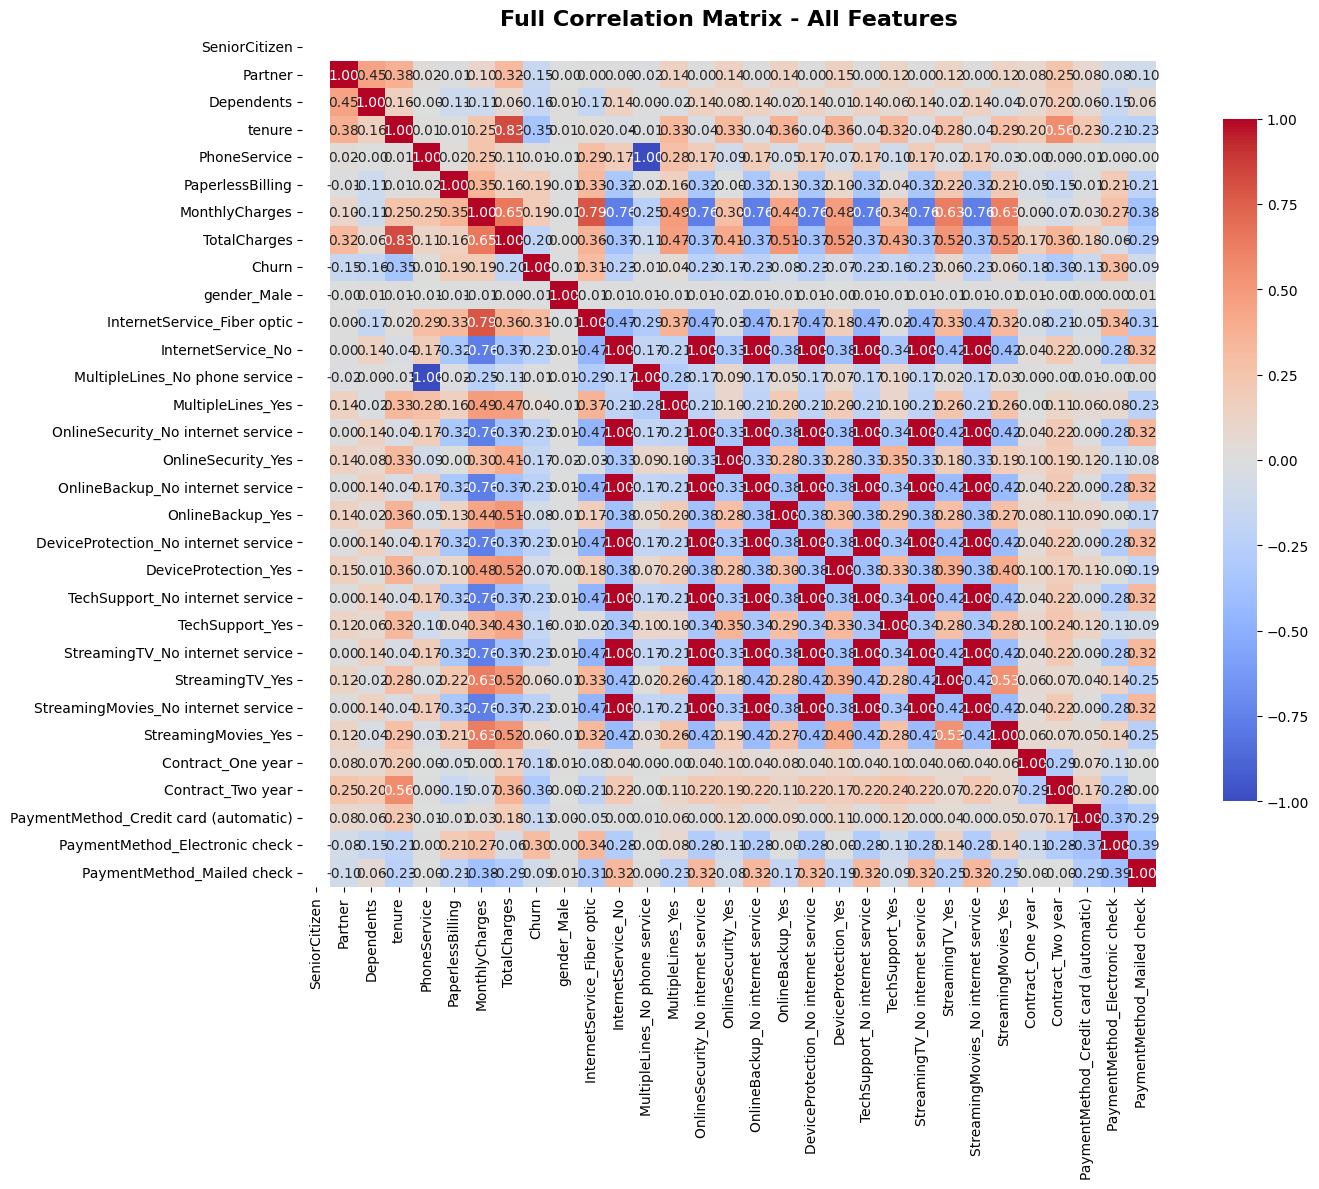

In [23]:
# Compute correlation matrix for all numeric columns
df_encoded=df_encoded.drop(columns=['customerID'], errors='ignore')  # Drop non-numeric ID column if it exists
corr_matrix = df_encoded.corr()

# Create a larger heatmap for better visibility
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={"shrink": 0.8}, square=True)
plt.title("Full Correlation Matrix - All Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


<b>Top Features Correlated with Churn</b>

Features Most Correlated with Churn (Top 10):
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService                      0.011942
gender_Male                      -0.008612
Name: Churn, dtype: float64


Features Least Correlated with Churn (Bottom 5):
StreamingMovies_No internet service   -0.227890
TechSupport_No internet service       -0.227890
Contract_Two year                     -0.302253
tenure                                -0.352229
SeniorCitizen                               NaN
Name: Churn, dtype: float64


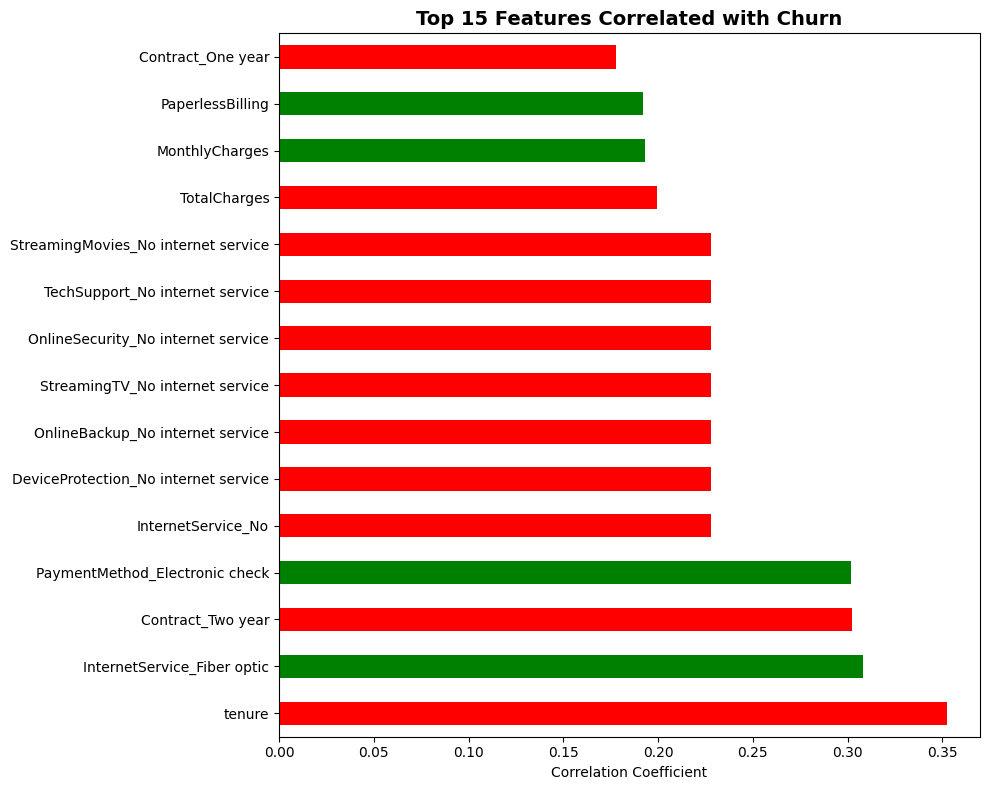

In [24]:
# Get correlations with Churn and sort
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

# Display top positive and negative correlations
print("Features Most Correlated with Churn (Top 10):")
print(churn_corr.head(10))
print("\n" + "="*50 + "\n")
print("Features Least Correlated with Churn (Bottom 5):")
print(churn_corr.tail(5))

# Visualize top correlations with Churn
plt.figure(figsize=(10, 8))
top_features = churn_corr.abs().sort_values(ascending=False)[1:16]  # Exclude Churn itself
colors = ['green' if x > 0 else 'red' for x in churn_corr[top_features.index]]
top_features.plot(kind='barh', color=colors)
plt.title("Top 15 Features Correlated with Churn", fontsize=14, fontweight='bold')
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()


<b>Key Insights from Correlation Analysis</b><br>
+ <b>Strong Positive Correlations with Churn:</b> Customers with shorter contract lengths, month-to-month billing, and no long-term commitments are more likely to churn<br>
+ <b>Strong Negative Correlations with Churn:</b> Longer tenure, tech support, and online security services reduce churn likelihood<br>
+ <b>Feature Selection Opportunity:</b> These highly correlated features should be prioritized in predictive models<br>
+ <b>Actionable Insights:</b> Focus retention efforts on month-to-month customers and encourage tech support adoption